In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import cartopy.feature as cfeature
import os
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
import xesmf as xe

In [2]:
home_path = os.path.expanduser("~")

path = '/DataFiles'
path2 = '/Library/Mobile Documents/com~apple~CloudDocs/Documents/Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium'

era5 = xr.open_dataset(home_path + path + "/ae3baa6a74f0aa315dc3de6f83298f0e.nc")
racmo = xr.open_dataset(home_path + path + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc")
mask = xr.open_dataset(home_path + path + "/TotIS_RACMO_ANT27_IMBIE2.nc")

folder = home_path + path 

In [5]:
ais_era5_base = np.load(folder + "/ERA5_AIS_BASE.npy")
wais_era5_base = np.load(folder + "/ERA5_WAIS_BASE.npy")
eais_era5_base = np.load(folder + "/ERA5_EAIS_BASE.npy")
ap_era5_base = np.load(folder + "/ERA5_AP_BASE.npy")

ais_era5_recon = np.load(folder + "/ERA5_AIS_RECON.npy")
wais_era5_recon = np.load(folder + "/ERA5_WAIS_RECON.npy")
eais_era5_recon = np.load(folder + "/ERA5_EAIS_RECON.npy")
ap_era5_recon = np.load(folder + "/ERA5_AP_RECON.npy")

ais_racmo_base = np.load(folder + "/RACMO_AIS_BASE.npy")
wais_racmo_base = np.load(folder + "/RACMO_WAIS_BASE.npy")
eais_racmo_base = np.load(folder + "/RACMO_EAIS_BASE.npy")
ap_racmo_base = np.load(folder + "/RACMO_AP_BASE.npy")

ais_racmo_recon = np.load(folder + "/RACMO_AIS_RECON.npy")
wais_racmo_recon = np.load(folder + "/RACMO_WAIS_RECON.npy")
eais_racmo_recon = np.load(folder + "/RACMO_EAIS_RECON.npy")
ap_racmo_recon = np.load(folder + "/RACMO_AP_RECON.npy")



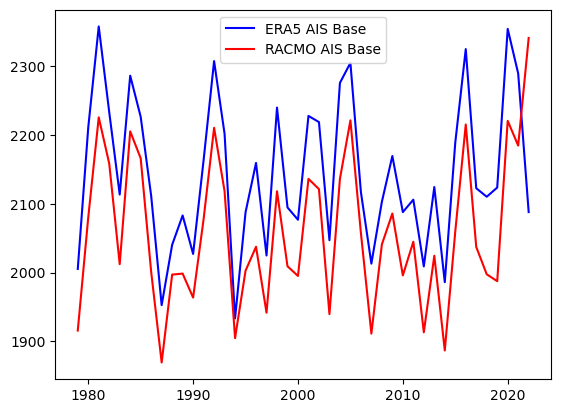

In [9]:
satYears = np.arange(1979, 2023)  # 1979-2022
reconYears = np.arange(1801, 2001)
midYears = np.arange(1979, 2001)

plt.plot(satYears, ais_era5_base, label='ERA5 AIS Base', color='blue')
plt.plot(satYears, ais_racmo_base, label='RACMO AIS Base', color='red')
plt.legend()

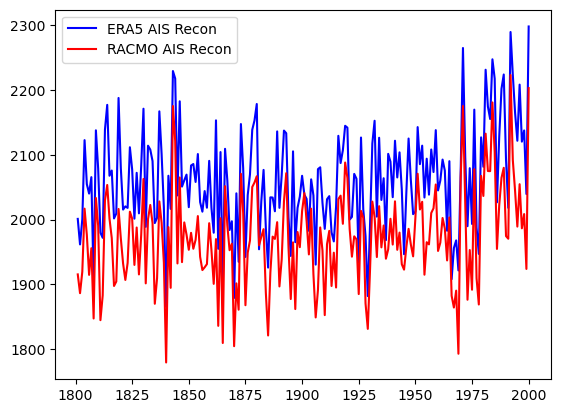

In [10]:
plt.plot(reconYears, ais_era5_recon, label='ERA5 AIS Recon', color='blue')
plt.plot(reconYears, ais_racmo_recon, label='RACMO AIS Recon', color='red')
plt.legend()

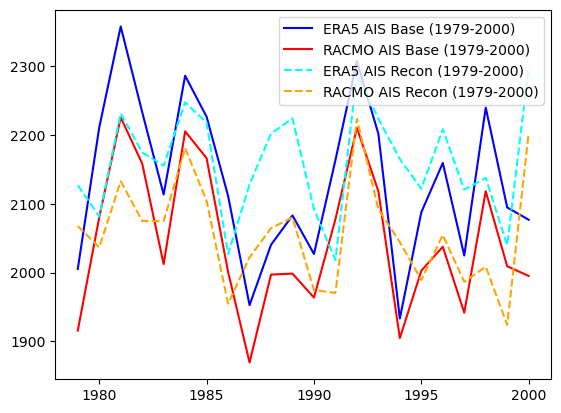

In [11]:
plt.plot(midYears, ais_era5_base[:22], label='ERA5 AIS Base (1979-2000)', color='blue')
plt.plot(midYears, ais_racmo_base[:22], label='RACMO AIS Base (1979-2000)', color='red')
plt.plot(midYears, ais_era5_recon[178:200], label='ERA5 AIS Recon (1979-2000)', color='cyan', linestyle='--')
plt.plot(midYears, ais_racmo_recon[178:200], label='RACMO AIS Recon (1979-2000)', color='orange', linestyle='--')
plt.legend()

In [15]:
print("AIS")
print("ERA5 Reality vs. RACMO Reality = " + np.corrcoef(ais_era5_base[:22], ais_racmo_base[:22])[0,1].astype(str))
print("ERA5 Reality vs. ERA5 Recon = " + np.corrcoef(ais_era5_base[:22], ais_era5_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. RACMO Recon = " + np.corrcoef(ais_racmo_base[:22], ais_racmo_recon[178:200])[0,1].astype(str))
print("ERA5 Recon vs. RACMO Recon = " + np.corrcoef(ais_era5_recon[178:200], ais_racmo_recon[178:200])[0,1].astype(str))
print("ERA5 Reality vs. RACMO Recon = " + np.corrcoef(ais_era5_base[:22], ais_racmo_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. ERA5 Recon = " + np.corrcoef(ais_racmo_base[:22], ais_era5_recon[178:200])[0,1].astype(str))

AIS
ERA5 Reality vs. RACMO Reality = 0.9774753757486322
ERA5 Reality vs. ERA5 Recon = 0.3466286101397674
RACMO Reality vs. RACMO Recon = 0.5117395303743425
ERA5 Recon vs. RACMO Recon = 0.9163351682831937
ERA5 Reality vs. RACMO Recon = 0.461466340461531
RACMO Reality vs. ERA5 Recon = 0.41174810362464936


In [16]:
print("WAIS")
print("ERA5 Reality vs. RACMO Reality = " + np.corrcoef(wais_era5_base[:22], wais_racmo_base[:22])[0,1].astype(str))
print("ERA5 Reality vs. ERA5 Recon = " + np.corrcoef(wais_era5_base[:22], wais_era5_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. RACMO Recon = " + np.corrcoef(wais_racmo_base[:22], wais_racmo_recon[178:200])[0,1].astype(str))
print("ERA5 Recon vs. RACMO Recon = " + np.corrcoef(wais_era5_recon[178:200], wais_racmo_recon[178:200])[0,1].astype(str))
print("ERA5 Reality vs. RACMO Recon = " + np.corrcoef(wais_era5_base[:22], wais_racmo_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. ERA5 Recon = " + np.corrcoef(wais_racmo_base[:22], wais_era5_recon[178:200])[0,1].astype(str))

WAIS
ERA5 Reality vs. RACMO Reality = 0.9493626882493268
ERA5 Reality vs. ERA5 Recon = 0.6653499355667004
RACMO Reality vs. RACMO Recon = 0.6718149138832471
ERA5 Recon vs. RACMO Recon = 0.9838729397712137
ERA5 Reality vs. RACMO Recon = 0.7011117733966892
RACMO Reality vs. ERA5 Recon = 0.6355970121312194


In [17]:
print("EAIS")
print("ERA5 Reality vs. RACMO Reality = " + np.corrcoef(eais_era5_base[:22], eais_racmo_base[:22])[0,1].astype(str))
print("ERA5 Reality vs. ERA5 Recon = " + np.corrcoef(eais_era5_base[:22], eais_era5_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. RACMO Recon = " + np.corrcoef(eais_racmo_base[:22], eais_racmo_recon[178:200])[0,1].astype(str))
print("ERA5 Recon vs. RACMO Recon = " + np.corrcoef(eais_era5_recon[178:200], eais_racmo_recon[178:200])[0,1].astype(str)) 
print("ERA5 Reality vs. RACMO Recon = " + np.corrcoef(eais_era5_base[:22], eais_racmo_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. ERA5 Recon = " + np.corrcoef(eais_racmo_base[:22], eais_era5_recon[178:200])[0,1].astype(str))

EAIS
ERA5 Reality vs. RACMO Reality = 0.9833474463878633
ERA5 Reality vs. ERA5 Recon = 0.2276885866164107
RACMO Reality vs. RACMO Recon = 0.37144295708200525
ERA5 Recon vs. RACMO Recon = 0.9512868878464734
ERA5 Reality vs. RACMO Recon = 0.3481518664862259
RACMO Reality vs. ERA5 Recon = 0.24360040504321834


In [18]:
print("AP")
print("ERA5 Reality vs. RACMO Reality = " + np.corrcoef(ap_era5_base[:22], ap_racmo_base[:22])[0,1].astype(str))
print("ERA5 Reality vs. ERA5 Recon = " + np.corrcoef(ap_era5_base[:22], ap_era5_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. RACMO Recon = " + np.corrcoef(ap_racmo_base[:22], ap_racmo_recon[178:200])[0,1].astype(str))
print("ERA5 Recon vs. RACMO Recon = " + np.corrcoef(ap_era5_recon[178:200], ap_racmo_recon[178:200])[0,1].astype(str)) 
print("ERA5 Reality vs. RACMO Recon = " + np.corrcoef(ap_era5_base[:22], ap_racmo_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. ERA5 Recon = " + np.corrcoef(ap_racmo_base[:22], ap_era5_recon[178:200])[0,1].astype(str))

AP
ERA5 Reality vs. RACMO Reality = 0.9882046178848789
ERA5 Reality vs. ERA5 Recon = 0.7793887303927406
RACMO Reality vs. RACMO Recon = 0.7105721144593948
ERA5 Recon vs. RACMO Recon = 0.9721176737627621
ERA5 Reality vs. RACMO Recon = 0.7451044865004912
RACMO Reality vs. ERA5 Recon = 0.761024123798416
